# 02 · Score Anatomy & Weight Sensitivity

The transition-risk score is a weighted sum of five min-max scaled components:

| Component | Default weight | Higher value means |
|---|---:|---|
| Recent CO2 trend | 0.30 | rising emissions |
| CO2 per capita | 0.20 | higher per-capita emissions |
| Carbon intensity | 0.20 | more CO2 per unit of energy |
| Fossil share of energy | 0.20 | more fossil dependence |
| Renewable electricity gap | 0.10 | *lower* renewable share |

This notebook opens the score up: it shows each component's **contribution** per country and tests how robust the ranking is to the choice of weights.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
REPORTS_DIR = REPO_ROOT / "reports" / "sample_run"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

# Build the lakehouse on demand so every notebook is runnable in isolation.
if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )
    print("Built DuckDB lakehouse.")
else:
    print("Reusing existing DuckDB lakehouse.")


Reusing existing DuckDB lakehouse.


## 1. Component contributions

Each weighted component adds up to the final score. Stacking them shows *why* a country scores the way it does, not just *how much*.

In [3]:
from carbon_transition_duckdb.pipeline import load_transition_mart
from carbon_transition_duckdb.risk.scoring import (
    ScoreWeights,
    add_driver_text,
    filter_entities,
    latest_year,
    score_transition_risk,
)

mart = filter_entities(load_transition_mart(DB_PATH))
scored = add_driver_text(score_transition_risk(mart))
year = latest_year(scored)

weights = ScoreWeights()
components = {
    'co2_trend_score': weights.co2_trend,
    'co2_per_capita_score': weights.co2_per_capita,
    'carbon_intensity_score': weights.carbon_intensity,
    'fossil_share_score': weights.fossil_share,
    'renewable_gap_score': weights.renewable_gap,
}
latest = scored.loc[scored['year'] == year].set_index('country')
contrib = pd.DataFrame(
    {name: latest[col] * w for col, w in components.items()
     for name in [col.replace('_score', '')]}
)
contrib = contrib.loc[latest['transition_risk_score'].sort_values().index]
contrib.round(2)

,co2_trend,co2_per_capita,carbon_intensity,fossil_share,renewable_gap
country,,,,,
Cyrenia,9.85,0.00,0.00,0.00,0.00
Estavia,6.97,0.51,3.47,2.81,1.63
Atlantis,12.10,10.16,11.53,11.83,5.37
Borealia,6.75,14.98,13.25,15.98,7.17
Deltora,13.50,13.79,13.41,18.59,9.47


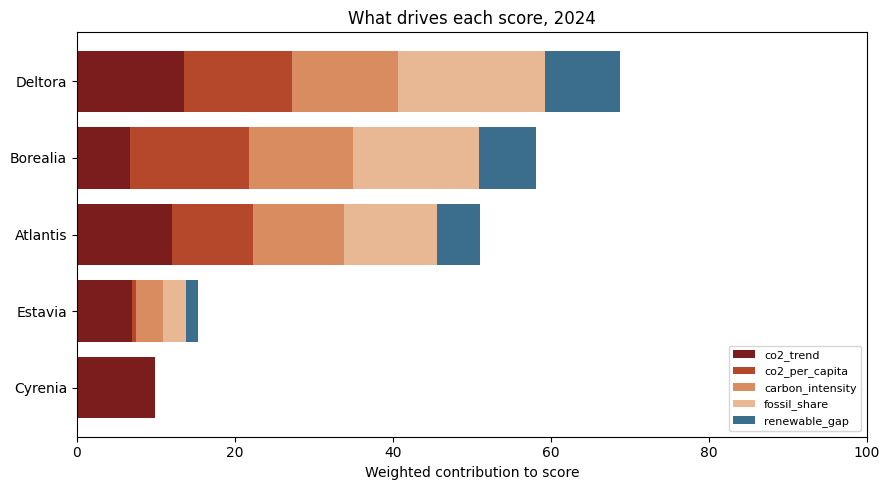

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
bottom = pd.Series(0.0, index=contrib.index)
colors = ['#7b1d1d', '#b5482a', '#d98c5f', '#e8b894', '#3b6e8c']
for color, col in zip(colors, contrib.columns, strict=False):
    ax.barh(contrib.index, contrib[col], left=bottom, label=col, color=color)
    bottom += contrib[col]
ax.set_xlabel('Weighted contribution to score')
ax.set_title(f'What drives each score, {year}')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

## 2. Weight sensitivity

Does the ranking survive a different emphasis? We rescore the same mart under several weight philosophies and compare the latest-year ordering.

In [5]:
scenarios = {
    'default': ScoreWeights(),
    'trend_heavy': ScoreWeights(co2_trend=0.50, co2_per_capita=0.15,
                                carbon_intensity=0.15, fossil_share=0.15,
                                renewable_gap=0.05),
    'per_capita_heavy': ScoreWeights(co2_trend=0.15, co2_per_capita=0.45,
                                     carbon_intensity=0.15, fossil_share=0.15,
                                     renewable_gap=0.10),
    'renewables_focused': ScoreWeights(co2_trend=0.20, co2_per_capita=0.15,
                                       carbon_intensity=0.15, fossil_share=0.20,
                                       renewable_gap=0.30),
    'equal': ScoreWeights(co2_trend=0.20, co2_per_capita=0.20,
                          carbon_intensity=0.20, fossil_share=0.20,
                          renewable_gap=0.20),
}

table = pd.DataFrame(index=sorted(mart['country'].unique()))
for name, w in scenarios.items():
    rescored = score_transition_risk(mart, weights=w)
    s = rescored.loc[rescored['year'] == year].set_index('country')['transition_risk_score']
    table[name] = s
table.round(1)

,default,trend_heavy,per_capita_heavy,renewables_focused,equal
Atlantis,51.0,48.0,51.8,52.3,52.3
Borealia,58.1,48.0,66.2,63.2,63.0
Cyrenia,9.8,16.4,4.9,6.6,6.6
Deltora,68.8,61.6,71.2,76.4,73.7
Estavia,15.4,17.5,11.0,15.3,14.7


In [6]:
ranks = table.rank(ascending=False).astype(int)
print('Rank by scenario (1 = highest risk):')
ranks

Rank by scenario (1 = highest risk):


,default,trend_heavy,per_capita_heavy,renewables_focused,equal
Atlantis,3,2,3,3,3
Borealia,2,2,2,2,2
Cyrenia,5,5,5,5,5
Deltora,1,1,1,1,1
Estavia,4,4,4,4,4


A slope chart makes rank movement obvious: flat lines mean the country's position is robust to the weighting; steep lines mean it is weight-sensitive.

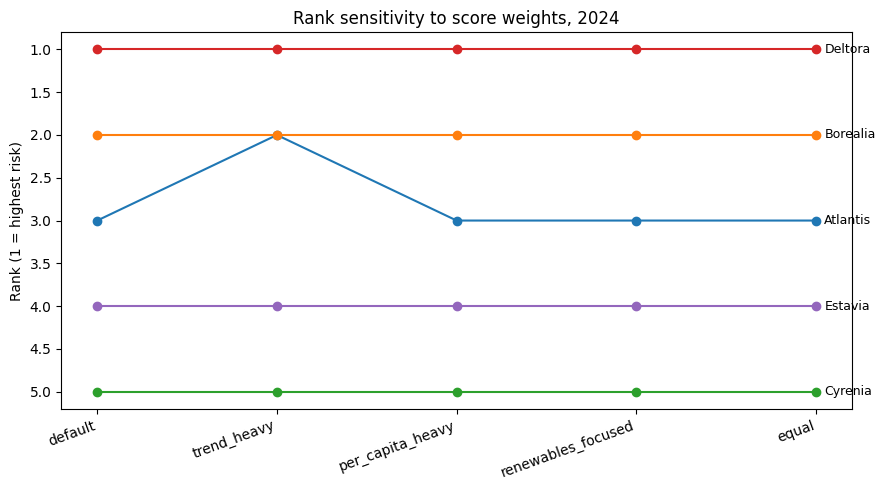

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(ranks.columns))
for country in ranks.index:
    ax.plot(x, ranks.loc[country], marker='o', label=country)
    ax.annotate(country, (x[-1], ranks.loc[country].iloc[-1]),
                xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(ranks.columns, rotation=20, ha='right')
ax.set_ylabel('Rank (1 = highest risk)')
ax.invert_yaxis()
ax.set_title(f'Rank sensitivity to score weights, {year}')
fig.tight_layout()
plt.show()

## 3. Dominant drivers

`risk_drivers` names the highest-scoring components per row — a quick, human-readable explanation of each screening signal.

In [8]:
(scored.loc[scored['year'] == year,
            ['country', 'transition_risk_score', 'risk_drivers']]
 .sort_values('transition_risk_score', ascending=False)
 .reset_index(drop=True))

,country,transition_risk_score,risk_drivers
0,Deltora,68.76,low renewable electricity share; high fossil-f...
1,Borealia,58.12,high fossil-fuel share; high CO2 per capita; l...
2,Atlantis,50.99,high fossil-fuel share; high carbon intensity;...
3,Estavia,15.39,recent CO2 emissions trend; high carbon intens...
4,Cyrenia,9.85,recent CO2 emissions trend; high CO2 per capit...


## Takeaways

- The score is fully decomposable — every point traces back to a named, min-max scaled component.
- Countries near the top/bottom tend to be stable across weightings; the **middle of the ranking is where weight choices matter most**.
- Because the components and weights are explicit, the score is auditable: there is no hidden model to second-guess.